In [1]:
# Importar librerías
import pandas as pd

# PRIMER AVANCE DEL PROYECTO

In [2]:
# Lectura del dataset
df = pd.read_csv("PFDA_People_analytics.csv",delimiter=';')
pd.set_option('display.max_rows', 200)      # Máximo 50 filas
# pd.set_option('display.max_columns', 36)    # Máximo 36 columnas
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
## set option: lo usamos para configurar las opciones de visualización de pandas y asi ver una mayor cantidad de filas y columnas del DataFrame.

### Exploración inicial del dataset 

In [3]:
# Visualización de los tres primeros registros del dataset
df.head(3)

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1.0,80,0,8,0,1,6,4,0,5
1,1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4.0,80,1,10,3,3,10,7,1,7
2,2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2.0,80,0,7,3,3,0,0,0,0


In [4]:
# Información general del dataset: Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1470 non-null   object 
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EmployeeNumber            1470 non-null   int64  
 11  EnvironmentSatisfaction   1470 non-null   int64  
 12  Gender                    1470 non-null   object 
 13  HourlyRate                1470 non-null   int64  
 14  JobInvol

Solo viendo esto podemos decir que no hay datos perdidos (aun no hemos hecho una exploracion para saber si existen valores duplicados o unicos en las diferentes columnas). Aun es demasiado pronto para determinar que columnas eliminar y cuales se usaran para el analisis (la columna Unnamed se presenta como una opcion a renombrar o eliminar, lo cual dependera de analisis siguientes).

In [5]:
# Dimensiones
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 1470 filas y 36 columnas.


In [6]:
# Columnas del dataset
df.columns

Index(['Unnamed: 0', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### Evaluación de calidad de datos

In [7]:
# Cambio de tipo de datos en las siguientes columnas
# A partir del análisis exploratorio, se observó que el tipo de datos de ciertos atributos no era el más adecuado. 
# Aunque originalmente fueron consideradas variables cuantitativas, en realidad corresponden a variables categóricas ordinales.
df['Education'] = pd.Categorical(df['Education'], categories=[1, 2, 3, 4, 5], ordered=True)
df['EnvironmentSatisfaction'] = pd.Categorical(df['EnvironmentSatisfaction'], categories=[1, 2, 3, 4], ordered=True)
df['JobLevel'] = pd.Categorical(df['JobLevel'], categories=[1, 2, 3, 4, 5], ordered=True)
df['JobInvolvement'] = pd.Categorical(df['JobInvolvement'], categories=[1, 2, 3, 4], ordered=True)
df['JobSatisfaction'] = pd.Categorical(df['JobSatisfaction'], categories=[1, 2, 3, 4], ordered=True)
df['PerformanceRating'] = pd.Categorical(df['PerformanceRating'], categories=[1, 2, 3, 4], ordered=True)
df['StockOptionLevel'] = pd.Categorical(df['StockOptionLevel'], categories=[0, 1, 2, 3], ordered=True)
df['WorkLifeBalance'] = pd.Categorical(df['WorkLifeBalance'], categories=[1, 2, 3, 4], ordered=True)

# Se realiza el cambio de tipo de datos para las columnas mencionadas, definiendo categorías ordenadas según su naturaleza ordinal.
# Se agrego 1, 2 en performance rating ya que en el dataset no existen registros con esos valores y se busca mantener la consistencia en la categorización.
# Esto permitirá un análisis más preciso y adecuado de estas variables en etapas posteriores del proyecto.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Unnamed: 0                1470 non-null   int64   
 1   Age                       1470 non-null   int64   
 2   Attrition                 1470 non-null   object  
 3   BusinessTravel            1470 non-null   object  
 4   DailyRate                 1470 non-null   int64   
 5   Department                1470 non-null   object  
 6   DistanceFromHome          1470 non-null   int64   
 7   Education                 1470 non-null   category
 8   EducationField            1470 non-null   object  
 9   EmployeeCount             1470 non-null   int64   
 10  EmployeeNumber            1470 non-null   int64   
 11  EnvironmentSatisfaction   1470 non-null   category
 12  Gender                    1470 non-null   object  
 13  HourlyRate                1470 non-null   int64 

In [8]:
# Revisar si existen valores nulos en el dataset
print("Columnas con valores nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])
# df.isnull() con esto vemos si hay valores nulos en el dataframe y con .sum() sumamos la cantidad de valores nulos por columna.
# [df.isnull().sum() > 0] con esto filtramos solo las columnas que tienen valores nulos mayores a 0.

Columnas con valores nulos:
OverTime                    30
RelationshipSatisfaction    30
dtype: int64


Se evidencia que existen valores nulos, para lo cual se analizará a detalle y se procederá a eliminar o imputar según corresponda.

In [9]:
# Visualización de los valores nulos
df[df[['OverTime', 'RelationshipSatisfaction']].isnull().any(axis=1)]

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
47,47,37,No,Travel_Rarely,408,Research & Development,19,2,Life Sciences,1,61,2,Male,73,3,1,Research Scientist,2,Married,3022,10227,4,Y,No,21,4,NaN,80,0,8,1,3,1,0,0,0
83,83,38,No,Non-Travel,573,Research & Development,6,3,Medical,1,107,2,Female,79,1,2,Research Scientist,4,Divorced,5329,15717,7,Y,NaN,12,3,4.0,80,3,17,3,3,13,11,1,9
127,127,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,1,167,4,Male,50,3,1,Sales Representative,3,Single,1675,26820,1,Y,NaN,19,3,4.0,80,0,0,2,2,0,0,0,0
149,149,19,No,Travel_Rarely,1181,Research & Development,3,1,Medical,1,201,2,Female,79,3,1,Laboratory Technician,2,Single,1483,16102,1,Y,No,14,3,NaN,80,0,1,3,3,1,0,0,0
196,196,35,No,Travel_Frequently,138,Research & Development,2,3,Medical,1,269,2,Female,37,3,2,Laboratory Technician,2,Single,4425,15986,5,Y,NaN,11,3,4.0,80,0,10,5,3,6,2,1,2
217,217,29,Yes,Travel_Rarely,992,Research & Development,1,3,Technical Degree,1,300,3,Male,85,3,1,Research Scientist,3,Single,2058,19757,0,Y,No,14,3,NaN,80,0,7,1,2,6,2,1,5
267,267,25,No,Non-Travel,675,Research & Development,5,2,Life Sciences,1,369,2,Male,85,4,2,Healthcare Representative,1,Divorced,4000,18384,1,Y,NaN,12,3,NaN,80,2,6,2,3,6,3,1,5
273,273,37,No,Travel_Rarely,228,Sales,6,4,Medical,1,378,3,Male,98,3,2,Sales Executive,4,Married,6502,22825,4,Y,NaN,14,3,2.0,80,1,7,5,4,5,4,0,1
320,320,27,No,Travel_Rarely,1377,Sales,2,3,Life Sciences,1,437,4,Male,74,3,2,Sales Executive,3,Single,4478,5242,1,Y,NaN,11,3,1.0,80,0,5,3,3,5,4,0,4
358,358,36,No,Non-Travel,845,Sales,1,5,Medical,1,479,4,Female,45,3,2,Sales Executive,4,Single,6653,15276,4,Y,NaN,15,3,2.0,80,0,7,6,3,1,0,0,0


In [10]:
## Se evidenció que Unnamed: 0 es un índice, por lo que no es relevante. 
## Así que, preferible eliminarla.
df = df.drop(columns=['Unnamed: 0'])

La columna OverTime es una columna tipo Yes o No, por lo cual no se le puede asignar un valor de forma indiscriminada, de la misma manera RelationshipSatisfaction es una columna cuyos valores son ordinales categóricos; como solución se plantea imputar Overtime y RelationshipSatisfaction con medida de tendencias central. Ahora, considerando la existencia de los nulos también podríamos verificar en conjunto a los valores únicos.

In [11]:
# Datos únicos en cada columna
df.nunique().reset_index().rename(columns={'index': 'columna', 0: 'n_valores_unicos'})

,columna,n_valores_unicos
0,Age,43
1,Attrition,2
2,BusinessTravel,3
3,DailyRate,886
4,Department,3
5,DistanceFromHome,29
6,Education,5
7,EducationField,6
8,EmployeeCount,1
9,EmployeeNumber,1470


Análisis 

A partir de la cantidad de valores únicos en las diferentes columnas, se observa que las siguientes columnas suelen tener el mismo valor para todos los registros:
   - EmployeeCount
   - Over18
   - StandardHours

Por tanto, estas columnas podrían eliminarse, ya que no aportan información relevante al ser constantes.

In [12]:
# Eliminar
df = df.drop(columns=['EmployeeCount', 'Over18','StandardHours'])

In [13]:
# Porcentajes de columnas con valores faltantes o nulos.
(df.isnull().sum()/df.shape[0])*100

Age                         0.000000
Attrition                   0.000000
BusinessTravel              0.000000
DailyRate                   0.000000
Department                  0.000000
DistanceFromHome            0.000000
Education                   0.000000
EducationField              0.000000
EmployeeNumber              0.000000
EnvironmentSatisfaction     0.000000
Gender                      0.000000
HourlyRate                  0.000000
JobInvolvement              0.000000
JobLevel                    0.000000
JobRole                     0.000000
JobSatisfaction             0.000000
MaritalStatus               0.000000
MonthlyIncome               0.000000
MonthlyRate                 0.000000
NumCompaniesWorked          0.000000
OverTime                    2.040816
PercentSalaryHike           0.000000
PerformanceRating           0.000000
RelationshipSatisfaction    2.040816
StockOptionLevel            0.000000
TotalWorkingYears           0.000000
TrainingTimesLastYear       0.000000
W

Análisis

- El porcentaje de valores nulos de las columnas 'OverTime' y 'RelationshipSatisfaction' es bajo (aproximadamente 2%), eliminar los registros implicaría pérdida de información.

Por tal razón, es preferible imputar los valores faltantes utilizando una medida de tendencia central.

In [14]:
# Observación de valores faltantes de la columna 'OverTime'
df[df['OverTime'].isnull()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
83,38,No,Non-Travel,573,Research & Development,6,3,Medical,107,2,Female,79,1,2,Research Scientist,4,Divorced,5329,15717,7,NaN,12,3,4.0,3,17,3,3,13,11,1,9
127,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,167,4,Male,50,3,1,Sales Representative,3,Single,1675,26820,1,NaN,19,3,4.0,0,0,2,2,0,0,0,0
196,35,No,Travel_Frequently,138,Research & Development,2,3,Medical,269,2,Female,37,3,2,Laboratory Technician,2,Single,4425,15986,5,NaN,11,3,4.0,0,10,5,3,6,2,1,2
267,25,No,Non-Travel,675,Research & Development,5,2,Life Sciences,369,2,Male,85,4,2,Healthcare Representative,1,Divorced,4000,18384,1,NaN,12,3,NaN,2,6,2,3,6,3,1,5
273,37,No,Travel_Rarely,228,Sales,6,4,Medical,378,3,Male,98,3,2,Sales Executive,4,Married,6502,22825,4,NaN,14,3,2.0,1,7,5,4,5,4,0,1
320,27,No,Travel_Rarely,1377,Sales,2,3,Life Sciences,437,4,Male,74,3,2,Sales Executive,3,Single,4478,5242,1,NaN,11,3,1.0,0,5,3,3,5,4,0,4
358,36,No,Non-Travel,845,Sales,1,5,Medical,479,4,Female,45,3,2,Sales Executive,4,Single,6653,15276,4,NaN,15,3,2.0,0,7,6,3,1,0,0,0
407,45,No,Travel_Rarely,192,Research & Development,10,2,Life Sciences,544,1,Male,69,3,1,Research Scientist,4,Married,2654,9655,3,NaN,21,4,4.0,2,8,3,2,2,2,0,2
465,46,No,Travel_Frequently,1034,Research & Development,18,1,Medical,624,1,Female,86,3,3,Healthcare Representative,3,Married,10527,8984,5,NaN,11,3,4.0,0,28,3,2,2,2,1,2
650,43,No,Travel_Frequently,422,Research & Development,1,3,Life Sciences,902,4,Female,33,3,2,Healthcare Representative,4,Married,5562,21782,4,NaN,13,3,2.0,1,12,2,2,5,2,2,2


Análisis

- Dado que 'OverTime' es una variable cualitativa nominal con valores YES o NO ; se realizará la imputación con la moda, ya que representa la categoría más frecuente y permite conservar la distribución original de los datos.

In [15]:
# Observación de valores faltantes de la columna 'RelationshipSatisfaction'
df[df['RelationshipSatisfaction'].isnull()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
47,37,No,Travel_Rarely,408,Research & Development,19,2,Life Sciences,61,2,Male,73,3,1,Research Scientist,2,Married,3022,10227,4,No,21,4,NaN,0,8,1,3,1,0,0,0
149,19,No,Travel_Rarely,1181,Research & Development,3,1,Medical,201,2,Female,79,3,1,Laboratory Technician,2,Single,1483,16102,1,No,14,3,NaN,0,1,3,3,1,0,0,0
217,29,Yes,Travel_Rarely,992,Research & Development,1,3,Technical Degree,300,3,Male,85,3,1,Research Scientist,3,Single,2058,19757,0,No,14,3,NaN,0,7,1,2,6,2,1,5
267,25,No,Non-Travel,675,Research & Development,5,2,Life Sciences,369,2,Male,85,4,2,Healthcare Representative,1,Divorced,4000,18384,1,NaN,12,3,NaN,2,6,2,3,6,3,1,5
410,30,No,Travel_Rarely,317,Research & Development,2,3,Life Sciences,548,3,Female,43,1,2,Manufacturing Director,4,Single,6091,24793,2,No,20,4,NaN,0,11,2,3,5,4,0,2
417,40,No,Travel_Rarely,1398,Sales,2,4,Life Sciences,558,3,Female,79,3,5,Manager,3,Married,18041,13022,0,No,14,3,NaN,0,21,2,3,20,15,1,12
486,37,No,Travel_Rarely,558,Sales,2,3,Marketing,656,4,Male,75,3,2,Sales Executive,3,Married,9602,3010,4,Yes,11,3,NaN,1,17,3,2,3,0,1,0
490,38,No,Travel_Rarely,362,Research & Development,1,1,Life Sciences,662,3,Female,43,3,1,Research Scientist,1,Single,2619,14561,3,No,17,3,NaN,0,8,3,2,0,0,0,0
541,36,No,Non-Travel,427,Research & Development,8,3,Life Sciences,742,1,Female,63,4,3,Research Director,1,Married,11713,20335,9,No,14,3,NaN,1,10,2,3,8,7,0,5
557,35,No,Non-Travel,1225,Research & Development,2,4,Life Sciences,771,4,Female,61,3,2,Healthcare Representative,1,Divorced,5093,4761,2,No,11,3,NaN,1,16,2,4,1,0,0,0


Análisis

- Dado que 'RelationshipSatisfaction' es una variable cualitativa/categórica ordinal con valores del 1 al 4 (donde 1 = Bajo, 2 = Medio, 3 = Alto, 4 = Muy Alto). En este caso, se realizará la imputación con la moda, ya que representa la categoría más frecuente y permite conservar la distribución original de los datos.

In [16]:
# Moda de RelationshipSatisfaction por grupo Department
df.groupby('Department')['RelationshipSatisfaction'].apply(lambda x: x.mode().iloc[0])

Department
Human Resources           3.0
Research & Development    3.0
Sales                     3.0
Name: RelationshipSatisfaction, dtype: float64

In [17]:
# Moda global de RelationshipSatisfaction
df['RelationshipSatisfaction'].mode()[0]

np.float64(3.0)

Análisis

- Se observó que al agrupar la columna 'RelationshipSatisfaction' por 'Department', su moda coincide con la moda global. 
- Por tanto, se continuará la imputación utilizando la moda general de 'RelationshipSatisfaction.


In [18]:
# Imputación de valores faltantes de la columna 'OverTime'
df['OverTime'] = df['OverTime'].fillna(df['OverTime'].mode()[0])


In [19]:
# Imputación de valores faltantes de la columna 'RelationshipSatisfaction'
df['RelationshipSatisfaction'] = df['RelationshipSatisfaction'].fillna(df['RelationshipSatisfaction'].mode()[0])


In [20]:
# Verificación de que ya no exista valores nulos
df.isnull().sum().reset_index().rename(columns={'index': 'columna', 0: 'n_valores_nulos'})

,columna,n_valores_nulos
0,Age,0
1,Attrition,0
2,BusinessTravel,0
3,DailyRate,0
4,Department,0
5,DistanceFromHome,0
6,Education,0
7,EducationField,0
8,EmployeeNumber,0
9,EnvironmentSatisfaction,0


In [21]:
# Cambio del tipo de dato
df['RelationshipSatisfaction'] = pd.Categorical(df['RelationshipSatisfaction'], categories=[1, 2, 3, 4], ordered=True)

In [22]:
# Estadística descriptiva
df.describe()

,Age,DailyRate,DistanceFromHome,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,1024.865306,65.891156,6502.931293,14313.103401,2.693197,15.209524,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,602.024335,20.329428,4707.956783,7117.786044,2.498009,3.659938,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,491.250000,48.000000,2911.000000,8047.000000,1.000000,12.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,1020.500000,66.000000,4919.000000,14235.500000,2.000000,14.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,1555.750000,83.750000,8379.000000,20461.500000,4.000000,18.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,2068.000000,100.000000,19999.000000,26999.000000,9.000000,25.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


In [23]:
df.describe().columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'HourlyRate',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [24]:
# Detectar posibles outliers en variables numéricas

# Función para detectar outliers usando IQR
def outliers(columna):
    #Verificación del tipo de dato, si la columna NO es numérica, devolver False en todas las filas
    if columna.dtype != 'int64' and columna.dtype != 'float64':
        return [False] * len(columna)
    
    # Si es numérica, calcula los outliers
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior  = Q3 + 1.5 * IQR
    return (columna < limite_inferior) | (columna > limite_superior)

# Aplicar la función a todo el DataFrame
outliers_df = df.apply(outliers)

# Resumen: cuántos outliers por columna
outliers_count = outliers_df.sum().sort_values(ascending=False)
outliers_count


TrainingTimesLastYear       238
MonthlyIncome               114
YearsSinceLastPromotion     107
YearsAtCompany              104
TotalWorkingYears            63
NumCompaniesWorked           52
YearsInCurrentRole           21
YearsWithCurrManager         14
Age                           0
Attrition                     0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
JobSatisfaction               0
JobRole                       0
JobLevel                      0
JobInvolvement                0
HourlyRate                    0
Gender                        0
EnvironmentSatisfaction       0
EmployeeNumber                0
RelationshipSatisfaction      0
PerformanceRating             0
PercentSalaryHike             0
OverTime                      0
MonthlyRate                   0
MaritalStatus                 0
WorkLifeBalance               0
StockOpt

In [25]:
# Veificar los outliers de las diferentes columnas numéricas 
columnas_outliers = df[['TrainingTimesLastYear', 'MonthlyIncome','YearsSinceLastPromotion','YearsAtCompany','TotalWorkingYears','NumCompaniesWorked','YearsInCurrentRole','YearsWithCurrManager']]

for col in columnas_outliers:
    outliers_bool = outliers(columnas_outliers[col])
    valores_outliers = columnas_outliers[col][outliers_bool]
    
    print(f"Outliers en la columna '{col}':")
    print(valores_outliers.value_counts())
    print("\n")

Outliers en la columna 'TrainingTimesLastYear':
TrainingTimesLastYear
5    119
6     65
0     54
Name: count, dtype: int64


Outliers en la columna 'MonthlyIncome':
MonthlyIncome
17328    2
17861    2
19545    1
19094    1
18740    1
18844    1
18172    1
18947    1
19537    1
17181    1
19926    1
19033    1
18722    1
19999    1
16792    1
16959    1
19232    1
19517    1
19202    1
19068    1
16872    1
19045    1
19144    1
19436    1
18665    1
17068    1
19272    1
18300    1
16659    1
19406    1
19197    1
17584    1
19566    1
18041    1
17046    1
16835    1
16595    1
19502    1
18200    1
16627    1
19513    1
19141    1
19189    1
16856    1
19859    1
18430    1
17639    1
16752    1
19246    1
17159    1
17924    1
17099    1
17444    1
17399    1
19419    1
18303    1
19973    1
19845    1
17650    1
19237    1
19627    1
16756    1
17665    1
16885    1
17465    1
19626    1
19943    1
18606    1
17048    1
17856    1
19081    1
17779    1
19740    1
18711    1
18265  

In [26]:
# Verificar los outliers de una columna específica como 'TotalWorkingYears'
outliers_bool = outliers(df['TotalWorkingYears'])
valores_outliers = df['TotalWorkingYears'][outliers_bool]
valores_outliers.value_counts().reset_index()

,TotalWorkingYears,count
0,29,10
1,31,9
2,32,9
3,33,7
4,30,7
5,36,6
6,34,5
7,37,4
8,35,3
9,40,2


In [61]:
# Verificar los outliers de una columna específica como 'YearsAtCompany'
outliers_bool = outliers(df['YearsAtCompany'])
valores_outliers = df['YearsAtCompany'][outliers_bool]
valores_outliers.value_counts().reset_index()

,YearsAtCompany,count
0,20,27
1,22,15
2,21,14
3,19,11
4,24,6
5,33,5
6,25,4
7,26,4
8,32,3
9,31,3


In [66]:
valores_outliers.value_counts().reset_index()['count'].sum()

np.int64(104)

Análisis:

- TrainingTimesLastYear: alta cantidad de outliers; posiblemente la mayoría de los empleados tiene pocas sesiones de entrenamiento, mientras que unos pocos tienen muchas sesiones o ninguna sesión de entrenamiento, generando una distribución sesgada.
- MonthlyIncome, YearsSinceLastPromotion, YearsAtCompany: los outliers podrían corresponder a empleados con antigüedad considerable, salarios superiores al promedio o promociones poco frecuentes.
- TotalWorkingYears, NumCompaniesWorked: los outliers reflejan algunos empleados con una trayectoria laboral extensa o con experiencia en múltiples empresas.
- YearsInCurrentRole, YearsWithCurrManager: muestran pocos outliers, lo que sugiere una distribución más homogénea en los valores altos.

Conclusión:
Los outliers detectados representan casos reales y relevantes (por ejemplo, empleados senior o con altos ingresos). Eliminarlos podría distorsionar la realidad y reducir la capacidad del análisis para identificar diferencias significativas entre diferentes perfiles.

No obstante, su presencia podría afectar métricas de tendencia central (como la media), la varianza y sesgar la distribución. Por tanto, en lugar de eliminarlos directamente, se debería realizar un análisis segmentado para minimizar su impacto sin perder información valiosa.

ANÁLISIS DE DISTRIBUCIóN DE VARIABLES

Análisis Exploratorio de variables

In [27]:
import matplotlib.pyplot as plt # Libreria de graficos
import seaborn as sns # Libreria de graficos estadisticos

sns.set(style="whitegrid", palette="muted") # Configuración del estilo de los gráficos

Iniciaremos observando los tipos de datos que tenemos, luego las separaremos por tipo

In [28]:
# Ver tipos de datos
df.dtypes.value_counts()

# Separar variables por tipo
num_cols = df.select_dtypes(include=['int64', 'float64']).columns # Selecciona columnas numéricas
cat_cols = df.select_dtypes(include=['object']).columns # Selecciona columnas categóricas
ord_cols = df.select_dtypes(include=['category']).columns # Selecciona columnas ordinales
# select_dtypes: selecciona columnas basadas en su tipo de dato.
print("Variables numéricas:", list(num_cols))
print("Variables categóricas:", list(cat_cols))
print("Variables ordinales:", list(ord_cols))

Variables numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Variables categóricas: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Variables ordinales: ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']


Con esto hecho podemos seleccionar mejor el tipo de gráfico en función al tipo de dato. Es decir, histogramas para variables númericas, barras para variables categóricas. 

Iniciaremos con la distribución de las variables numéricas.

<Figure size 1000x800 with 0 Axes>

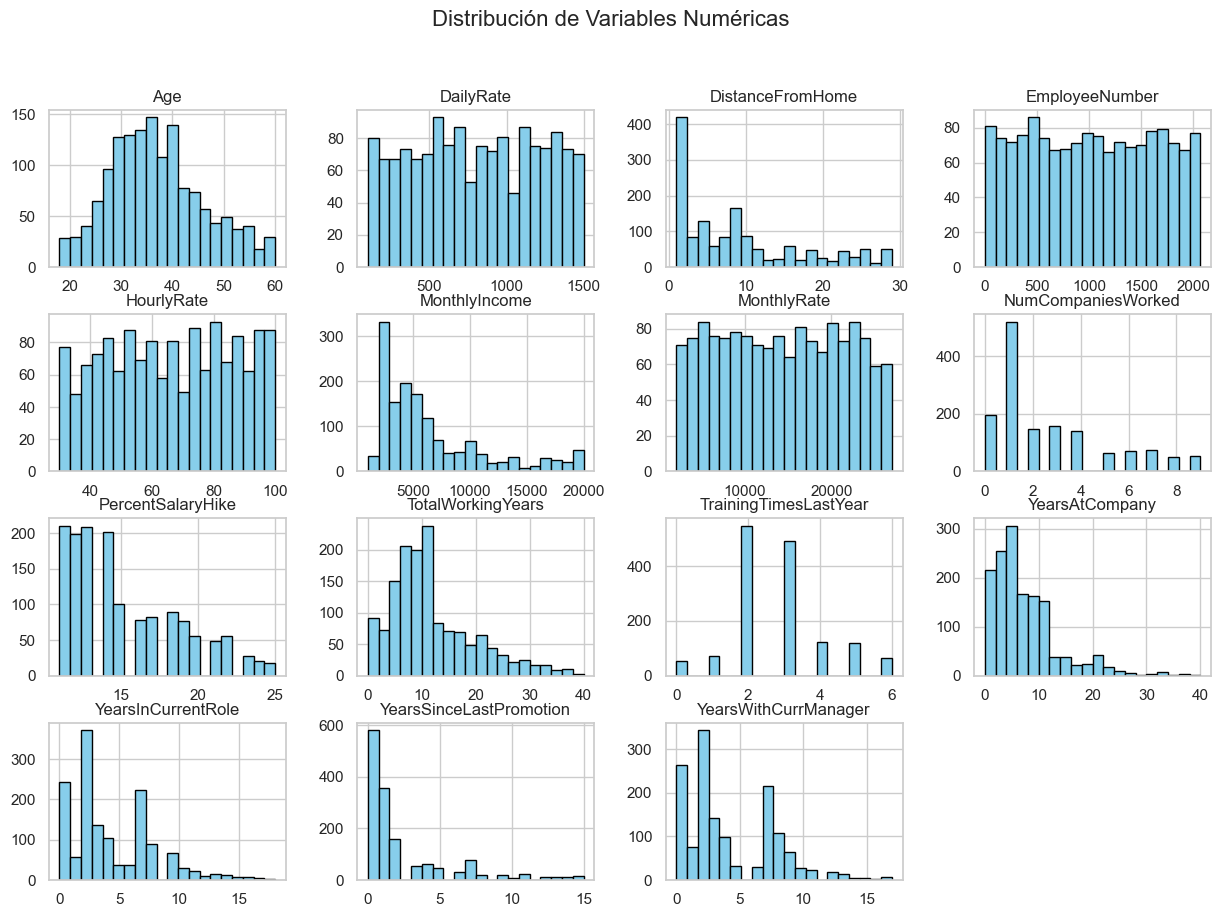

In [29]:
plt.figure(figsize=(10, 8)) # Ajuste del tamaño de la figura (Pense en (15,10) pero era muy grande)
df[num_cols].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black') # Histograma de variables numéricas
plt.suptitle('Distribución de Variables Numéricas', fontsize=16) # Título general del gráfico
plt.show() # Mostrar el gráfico

Antes de hacer un analisis de los graficos presentados se debe aclarar que el eje x representa a la variable mientras que el eje y representa la cantidad de empleados. 
Con ello en mente podemos notar de mamera especifica:
- Los trabajadores se encuentran en un rango entre 30 y 40 años, se observa que se encuentran en edad laboral media. Por su distribucion que se asemeja a la forma de una campana se puede decir que es una forma aproximada a la distribucion normal. 
- En MonthlyRate existe un notable sesgo hacia la derecha, lo cual nos dice que muchos empleados ganan menos de 5000 pero existen empleados con salarios muy alto. Lo cual nos estaria indicando una disparidad salarial o una fuerte jerarquia salarial.
- Tanto en YearsAtCompany como en YearsInCurrentRole nos dicen que muchos empleados tienen pocos años de experencia en la compañia como en su rol actual, aquello podria indicar una alta rotacion de empleados o baja antiguedad.
- En cuanto a DistanceFromHome podemos notar que los empleados en gran mayoria viven cerca de la empresa y muy pocos lejos de la misma, lo cual es tipico de empresas ubicadas en zonas urbanas.
- Y por ultimo, NumCompaniesWorked nos habla de un pico donde se muestra que los empleados han trabajado en una compañia, tal que sugiere un ingreso temprano al mercado laboral (Es decir una carrera temprana) o estabilidad laboral
De forma general:
- La mayoría de las variables muestran asimetría positiva (sesgo a la derecha) → muchos valores pequeños y pocos grandes.
- Se reflejan estructuras jerárquicas (pocos empleados con altos salarios, mucha experiencia o cargos altos).
- Hay algunas variables (como edad o tasa salarial) con distribución más uniforme o normal.
 

Ahora indagaremos en las relaciones entre variables numéricas (correlaciones)

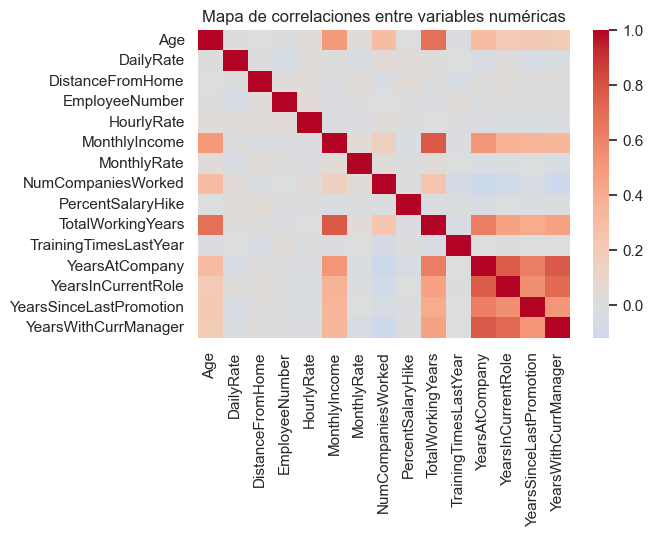

In [30]:
plt.figure(figsize=(6, 4)) # Ajuste del tamaño de la figura
corr = df[num_cols].corr() # Cálculo de la matriz de correlación
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False) # Mapa de calor de la matriz de correlación
plt.title("Mapa de correlaciones entre variables numéricas") # Título del gráfico
plt.show() # Mostrar el gráfico

Sobre la correlacion podemos decir que no se evidencia una correlacion negativa significativa entre las variables.
- Entre las correlaciones mas notables tenemos YearsInCurrentRole con YearsAtCompany, nos habla que a medida que pasan años en la compañia desempeñan un mismo rol a lo largo del tiempo.
- Age y TotalWorkingYear nos habla de que entre mas años de experiencia tenga un empleado mayor sera su edad.
- MonthlyIncome tiene una correlacion positiva con TotalWorkinYears.




Pasaremos a analizar las varibles categoricas

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\2957254781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.countplot(data=df, x=col, palette='coolwarm') # Gráfico de conteo
C:\Users\USER\AppData\Local\Temp\ipykernel_48180\2957254781.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(labels, rotation=40, ha='right') # Rotar etiquetas para mejor visibilidad
C:\Users\USER\AppData\Local\Temp\ipykernel_48180\2957254781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.countplot(data=df, x=col, palette='coolwarm') # Gráfico de conteo
C:\Users\USER\AppData\Local\Temp\ipykernel_48180\2957

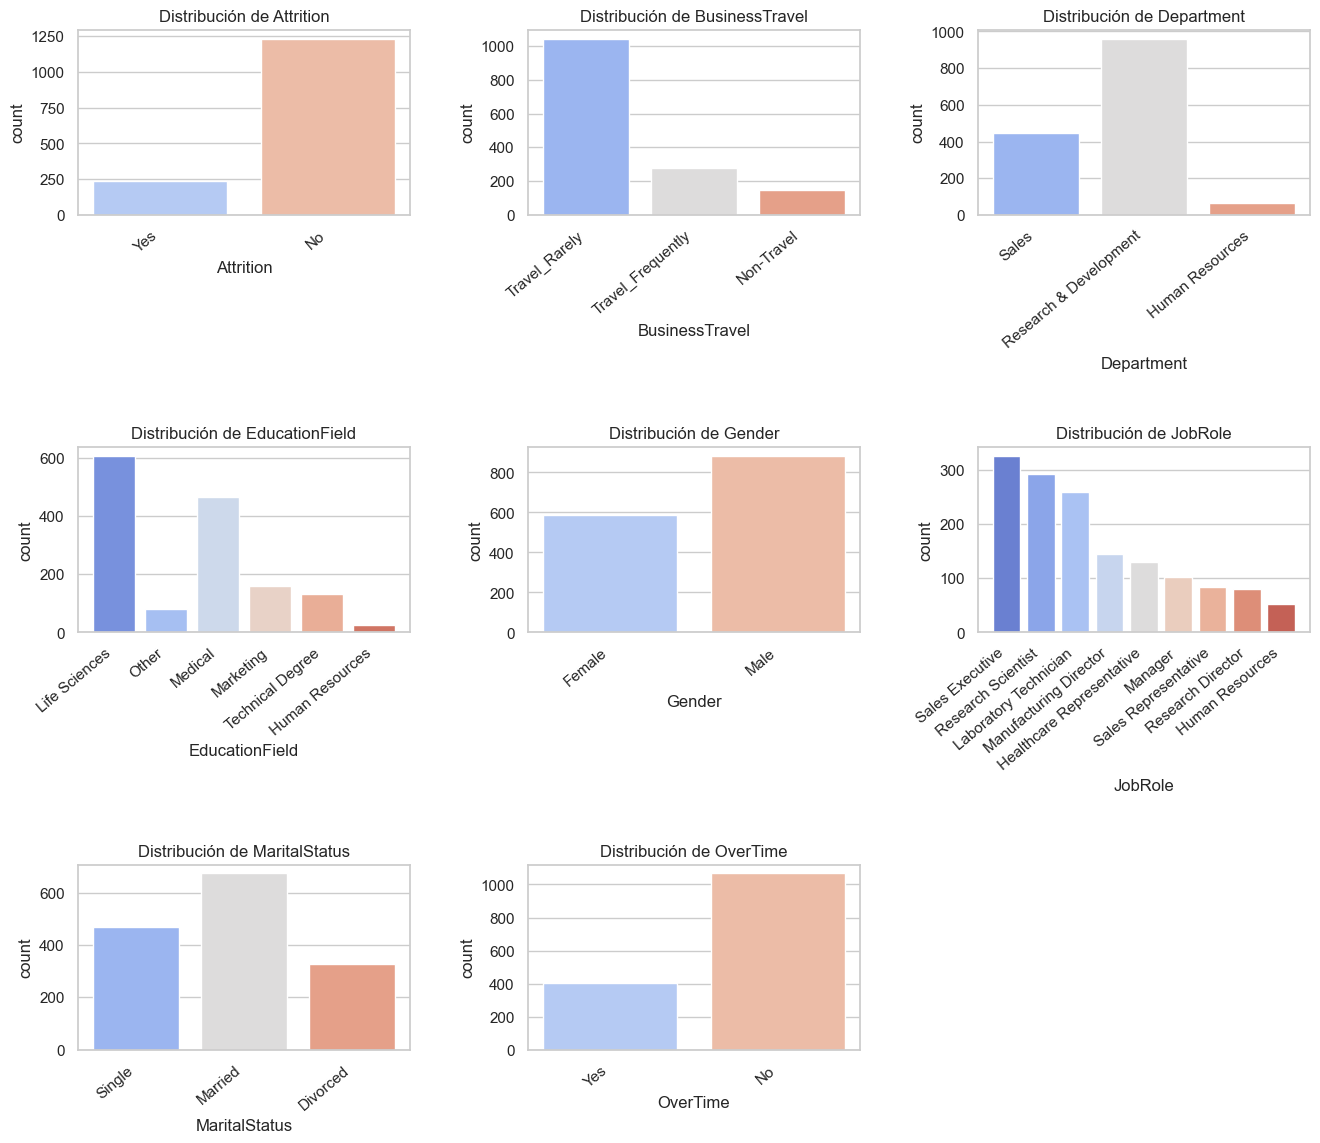

In [31]:
plt.figure(figsize=(14, 12))  # Ajuste del tamaño de la figura
for i, col in enumerate(cat_cols, 1): # Iterar sobre columnas categóricas
    plt.subplot(3, 3, i) # Crear subgráfico
    plot = sns.countplot(data=df, x=col, palette='coolwarm') # Gráfico de conteo
    plt.title(f'Distribución de {col}') # Título del subgráfico
    # Ajustar las etiquetas
    labels = plot.get_xticklabels() # Obtener etiquetas del eje X
    plot.set_xticklabels(labels, rotation=40, ha='right') # Rotar etiquetas para mejor visibilidad
    # Ajustar límites del eje X para centrar mejor
    plt.margins(x=0.05) # Ajuste de márgenes en el eje X

plt.tight_layout(pad=3.0)  # Ajuste automático del diseño con espacio entre subgráficos
plt.subplots_adjust(bottom=0.1, top=0.95)  # Ajuste de los márgenes superior e inferior
plt.show() # Mostrar el gráfico



Se puede señalar que:
- Attrition (es un indicador que habla sobre el desgate o disminucion del personal) podemos ver como este concentra valores en NO lo cual nos puede indicar que existe un bajo nivel de rotacion o un bajo desgate del personal.
- En cuanto a la frecuencia de viajes de negocios predomina rara vez.
- Research and Development concentra gran cantidad del personal.
- En cuanto a los estudios predominan los empleados con formacion medica o en ciencias de la vida.
- Hay mayor cantidad de empleados masculinos.
- En cuanto a roles desempeñados los roles que predominan son Sales Executive, Research Scientist y Laboratory Technician, lo cual podemos notar como se relaciona con el campo de estudio de los empleados.
- En cuanto a las horas extras predomina el NO.

Continuamos analizando la distribucion de las variables ordinales

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1808163116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='crest') # Gráfico de conteo
C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1808163116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='crest') # Gráfico de conteo
C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1808163116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='crest') # Gráfico de conteo
C:\Users\USER\AppData\Local\Temp\ipykernel_481

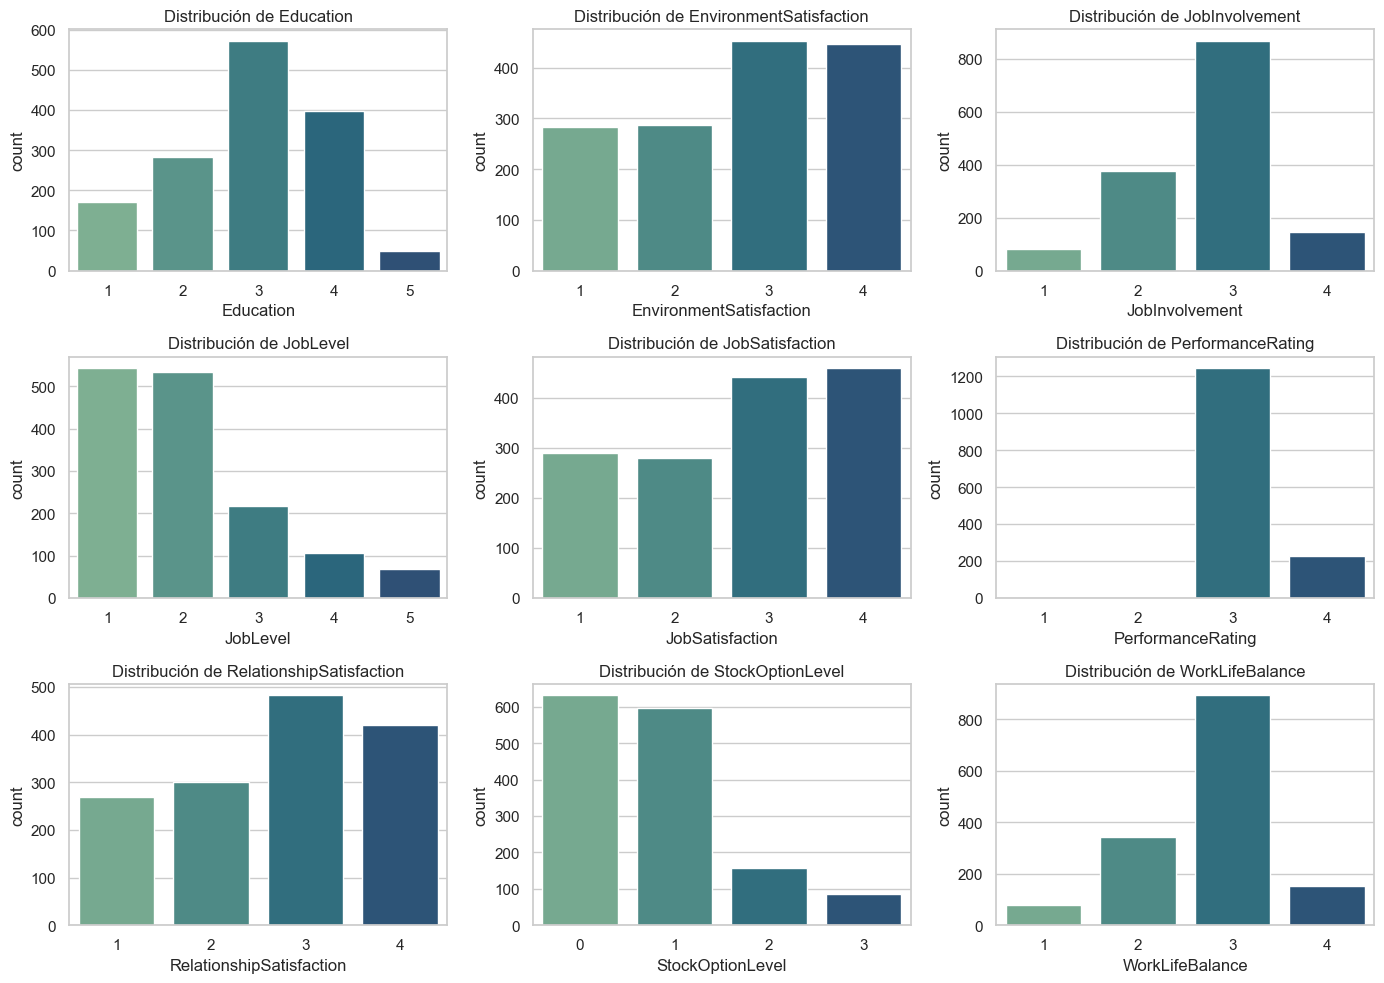

In [32]:
plt.figure(figsize=(14, 10)) # Ajuste del tamaño de la figura
for i, col in enumerate(ord_cols, 1): # Iterar sobre columnas ordinales
    plt.subplot(3, 3, i) # Crear subgráfico
    sns.countplot(data=df, x=col, palette='crest') # Gráfico de conteo
    plt.title(f'Distribución de {col}') # Título del subgráfico
plt.tight_layout() # Ajuste automático del diseño
plt.show() # Mostrar el gráfico

En base a lo observado tenemos que:
- La mayoría de empleados posee un nivel educativo medio (nivel 3), mientras que pocos alcanzan niveles superiores.
- Predominan los niveles altos de satisfacción ambiental (3 y 4), indicando conformidad con el entorno laboral.
- La mayor parte del personal muestra una alta implicación en su trabajo (nivel 3), reflejando compromiso generalizado.
- La mayoría se concentra en niveles laborales bajos o medios (1 y 2), con pocos empleados en puestos superiores.
- Los niveles de satisfacción laboral son altos (3 y 4), lo que sugiere una percepción positiva del empleo.
- Casi todos los empleados tienen una calificación de desempeño de 3, evidenciando evaluaciones uniformes.
- La satisfacción con las relaciones interpersonales también es elevada (niveles 3 y 4), mostrando buen clima social.
- Predominan los niveles bajos de opciones sobre acciones (0 y 1), lo que indica beneficios limitados en este aspecto.
- La mayoría percibe un buen equilibrio entre trabajo y vida personal (nivel 3).


En conjunto, los empleados presentan altos niveles de satisfacción y compromiso, con condiciones laborales favorables y un entorno positivo. Sin embargo, la estructura organizacional se concentra en niveles jerárquicos bajos y con beneficios financieros moderados, lo que podría reflejar una fuerza laboral numerosa en posiciones operativas.

Ahora, realizaremos un analices que tome en consideracion la relacion entre dos o mas variables (ejem: analizar variables numericas junto con ordinales y viceversa)

Relaciones entre variables categóricas y numéricas

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1137415629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='MonthlyIncome', palette='Set2') # Gráfico de caja para MonthlyIncome por género


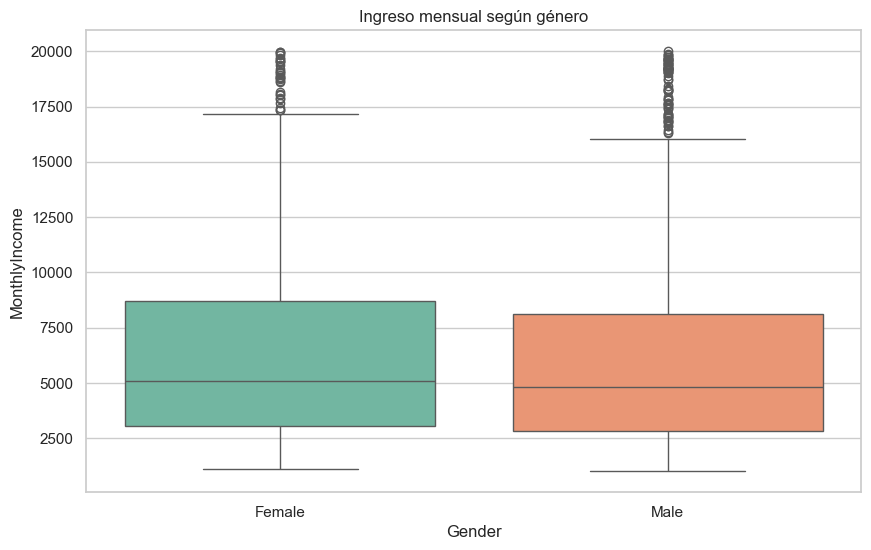

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1137415629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='MonthlyIncome', palette='pastel') # Gráfico de caja para MonthlyIncome por departamento


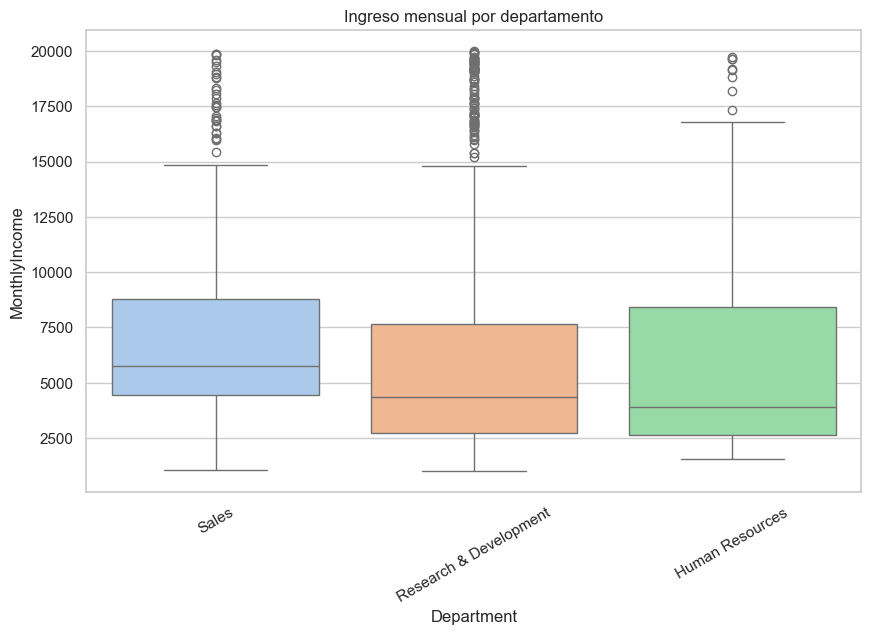

In [33]:
plt.figure(figsize=(10, 6)) # Ajuste del tamaño de la figura
sns.boxplot(data=df, x='Gender', y='MonthlyIncome', palette='Set2') # Gráfico de caja para MonthlyIncome por género
plt.title('Ingreso mensual según género') # Título del gráfico
plt.show() # Mostrar el gráfico
plt.figure(figsize=(10, 6)) # Ajuste del tamaño de la figura
sns.boxplot(data=df, x='Department', y='MonthlyIncome', palette='pastel') # Gráfico de caja para MonthlyIncome por departamento
plt.title('Ingreso mensual por departamento') # Título del gráfico
plt.xticks(rotation=30) # Rotar etiquetas del eje X
plt.show() # Mostrar el gráfico

- En el grafico donde vemos el ingreso mensual por genero podemos notar que no hay una brecha significate en el salario de hombres y mujeres, lo que si es evidente es la presencia de outliers para ambos generos.
- En el segundo grafico podemos observarque existe una brecha entre departamentos, el departamento de ventas se diferencia en salario con respecto a los demas departamentos.
- Existen muchos outliers en el departamento de Research & Development

Relaciones entre dos variables categóricas

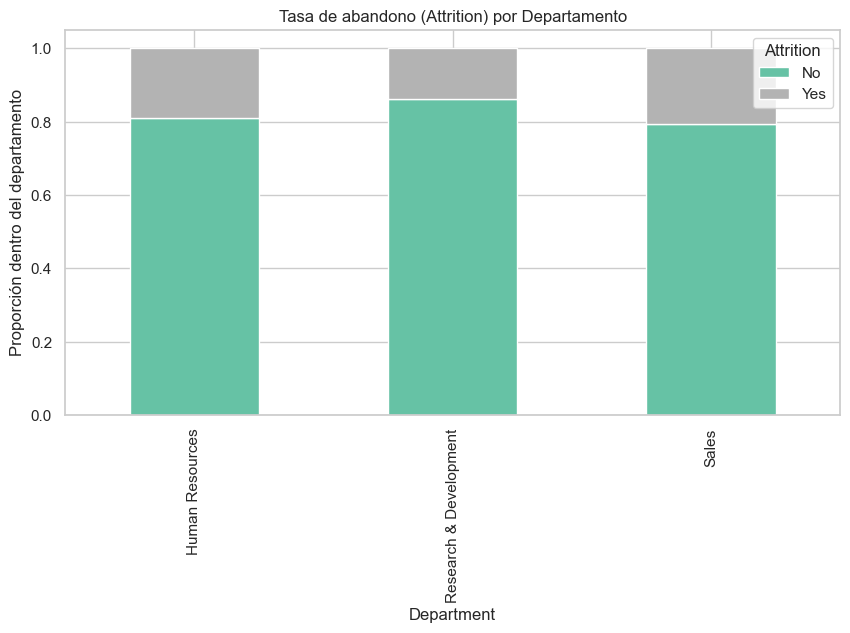

In [34]:
# Tabla cruzada
cross_tab = pd.crosstab(df['Department'], df['Attrition'], normalize='index') # Normalización por fila
# Gráfico
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2') # Gráfico de barras apiladas
plt.title('Tasa de abandono (Attrition) por Departamento') # Título del gráfico
plt.ylabel('Proporción dentro del departamento') #  Etiqueta del eje Y
plt.show() # Mostrar el gráfico

Con este codigo podemos notar la rotacion o desgaste del personal segun su departamento, como podemos observar en el departamento de ventas tiene mayor proporcion de rotacion, aunque no podemos señalar que sea una diferencia significativa. 

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\3447511902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='JobSatisfaction', palette='pastel') # Gráfico de caja para JobSatisfaction por departamento


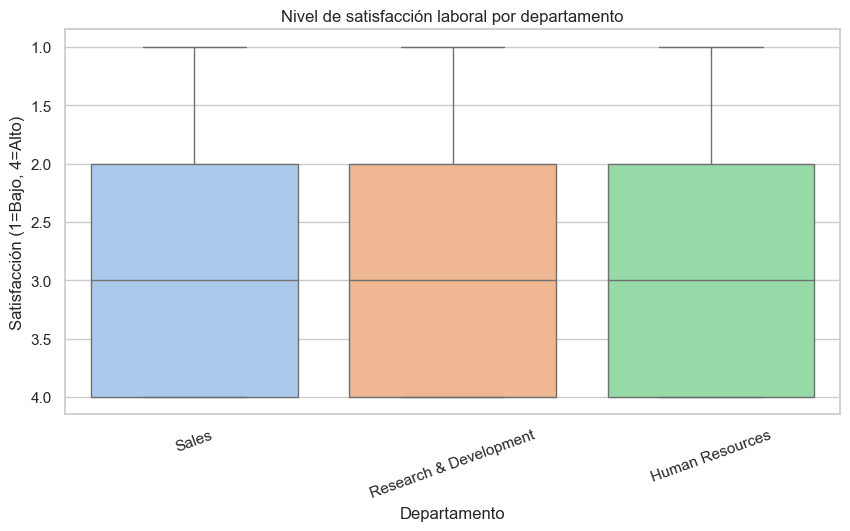

In [35]:
plt.figure(figsize=(10, 5)) # Ajuste del tamaño de la figura
sns.boxplot(data=df, x='Department', y='JobSatisfaction', palette='pastel') # Gráfico de caja para JobSatisfaction por departamento
plt.title('Nivel de satisfacción laboral por departamento') # Título del gráfico
plt.xlabel('Departamento') # Etiqueta del eje X
plt.ylabel('Satisfacción (1=Bajo, 4=Alto)') # Etiqueta del eje Y
plt.xticks(rotation=20) # Rotar etiquetas del eje X
plt.show() # Mostrar el gráfico

Podemos notar que no existe mucha diferencia cuando hablamos de satisfaccion laboral entre los distintos departamentos. Al tener una media de tres nos dice que los empleados se encuentran bastante satisfechos, en caso de que fuese menor estariamos frente a un area a considerar dentro de la empresa.

# AVANCE FINAL DEL PROYECTO

## Análisis 1. Retención y rotación de personal

## Preguntas que se buscan responder:

### P1.- ¿Qué factores laborales, como la satisfacción, el salario o las horas extra, se asocian con una mayor probabilidad de rotación?

### P2.- ¿Existe relación entre la antigüedad y la formación recibida con la decisión de permanecer en la empresa?

In [36]:
# Discretizar variable YearsAtCompany
df['YearsAtCompany_binned'] = pd.qcut(df['YearsAtCompany'], q = 4, labels=['0-3', '3-5', '5-9', '9-40'])

In [37]:
# Tabla cruzada de porcentaje de rotación por Años en la compañía
ct_y = pd.crosstab(df['YearsAtCompany_binned'], df['Attrition'], normalize='index') * 100
ct_y

Attrition,No,Yes
YearsAtCompany_binned,,
0-3,74.042553,25.957447
3-5,86.928105,13.071895
5-9,88.719512,11.280488
9-40,89.617486,10.382514


In [38]:
# Tabla cruzada de porcentaje de rotación por Educación
ct_e = pd.crosstab(df['Education'], df['Attrition'], normalize='index') * 100
ct_e

Attrition,No,Yes
Education,,
1,81.764706,18.235294
2,84.397163,15.602837
3,82.692308,17.307692
4,85.427136,14.572864
5,89.583333,10.416667


In [ ]:
# Tabla cruzada de porcentaje de rotación por Años en la compañía y Educación
ct_ye = pd.crosstab(index = [df['YearsAtCompany_binned'],df['Education']], columns= df['Attrition'], normalize='index') * 100
ct_ye

Attrition                                No        Yes
YearsAtCompany_binned Education                       
0-3                   1           73.333333  26.666667
                      2           72.941176  27.058824
                      3           68.717949  31.282051
                      4           83.035714  16.964286
                      5           83.333333  16.666667
3-5                   1           84.210526  15.789474
                      2           86.764706  13.235294
                      3           87.068966  12.931034
                      4           87.341772  12.658228
                      5          100.000000   0.000000
5-9                   1           84.848485  15.151515
                      2           88.235294  11.764706
                      3           90.082645   9.917355
                      4           87.755102  12.244898
                      5          100.000000   0.000000
9-40                  1           89.743590  10.256410
                      2           93.442623   6.557377
                      3           92.142857   7.857143
                      4           84.403670  15.596330
                      5           88.235294  11.764706

In [60]:
# Calcular tamaño de cada grupo
df.groupby(['YearsAtCompany_binned', 'Education']).size().reset_index(name='n')

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1490364784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['YearsAtCompany_binned', 'Education']).size().reset_index(name='n')


,YearsAtCompany_binned,Education,n
0,0-3,1,60
1,0-3,2,85
2,0-3,3,195
3,0-3,4,112
4,0-3,5,18
5,3-5,1,38
6,3-5,2,68
7,3-5,3,116
8,3-5,4,79
9,3-5,5,5


In [63]:
# Calcular tamaño de cada grupo
pd.crosstab(index=[df['YearsAtCompany_binned'], df['Education']], columns = df['Attrition'])

Attrition                         No  Yes
YearsAtCompany_binned Education          
0-3                   1           44   16
                      2           62   23
                      3          134   61
                      4           93   19
                      5           15    3
3-5                   1           32    6
                      2           59    9
                      3          101   15
                      4           69   10
                      5            5    0
5-9                   1           28    5
                      2           60    8
                      3          109   12
                      4           86   12
                      5            8    0
9-40                  1           35    4
                      2           57    4
                      3          129   11
                      4           92   17
                      5           15    2

Interpretación:
- Se evidencia una relación entre antigüedad y decisión de permanencia: los empleados más nuevos (0-3 años) son los más propensos a irse.

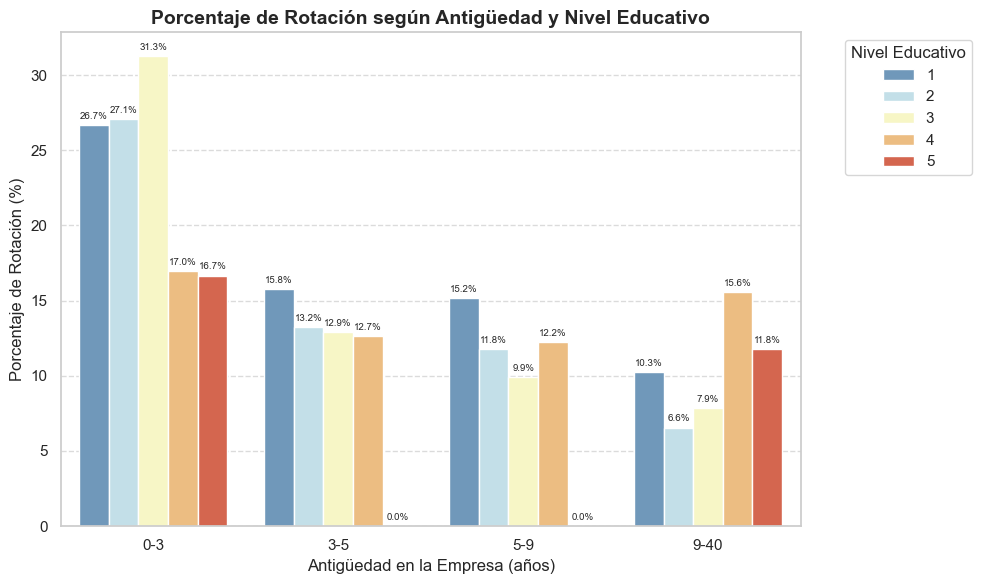

In [55]:
# Dimensiones del gráfico
plt.figure(figsize=(10,6))

# Gráfico de barras agrupadas
barplot= sns.barplot(data=ct_ye['Yes'].reset_index(), x='YearsAtCompany_binned', y='Yes', hue='Education', palette='RdYlBu_r')

# Añadir etiquetas de porcentaje sobre cada barra
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=7, padding=3)

# Estilo de títulos y etiquetas
plt.title('Porcentaje de Rotación según Antigüedad y Nivel Educativo', fontsize=14, fontweight='bold')
plt.xlabel('Antigüedad en la Empresa (años)', fontsize=12)
plt.ylabel('Porcentaje de Rotación (%)', fontsize=12)
plt.legend(title='Nivel Educativo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar diseño
plt.tight_layout()
# Mostrar gráfico
plt.savefig("grafico_transparente.png", transparent=True, dpi=300)
plt.show()

Interpretación:
- Antigüedad y retención:
    - Los empleados con menor antigüedad (0-3 años) presentan tasas más altas de rotación ( aprox. 26–31 %), lo que sugiere que los primeros años son críticos para la retención.
    - A medida que la antigüedad aumenta (3-5, 5-9, 9-40 años), la rotación disminuye notablemente, llegando a cifras aprox. de 7–12 % en la mayoría de los grupos.

Insight: Existe una relación inversa entre antigüedad y probabilidad de renunciar: a más tiempo en la empresa, menor intención de salida.

- Nivel educativo y retención
    - En los niveles educativos más bajos (1–2), las tasas de rotación son ligeramente más altas que en niveles intermedios o altos (3–5). Sin embargo, la diferencia se reduce con la antigüedad: entre quienes tienen más de 9 años, incluso los de menor educación muestran alta permanencia.

Insight: la formación influye principalmente en los primeros años; con el tiempo, la experiencia pesa más que la educación en la decisión de permanecer.

Patrones detectados:
- Riesgo temprano: empleados con educación media (3) y poca antigüedad (0-3 años) muestran la rotación más alta ( aprox. 31 %).
- Lealtad alta en niveles educativos altos y antigüedad media-alta: empleados con educación 5 y más de 3 años tienen 0 % de rotación.

### P3.- ¿Qué combinación de factores predice con mayor precisión el abandono del puesto?

In [41]:
# Discretizar variable Age
df['Age_binned'] = pd.cut(df['Age'], bins=[17,29,44,60], labels=['Joven','Adulto joven','Adulto mayor'])

In [42]:
# Tabla cruzada de porcentaje de rotación por Edad
age_tab = pd.crosstab(df['Age_binned'],df['Attrition'], normalize ='index')*100
age_tab

Attrition,No,Yes
Age_binned,,
Joven,72.085890,27.914110
Adulto joven,86.746988,13.253012
Adulto mayor,88.535032,11.464968


Interpretación: 
- Se evidencia que aprox. 28% de jóvenes salen de la empresa, mientras que los empleados de mayor edad presentan una menor tasa de rotación, lo que sugiere que la edad influye de manera moderada.

In [43]:
# Tabla cruzada de porcentaje de rotación por Género
gender_tab = pd.crosstab(df['Gender'],df['Attrition'], normalize ='index')*100
gender_tab

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


Interpretación: 
- En general, los hombres tienen una tasa de rotación (attrition) ligeramente mayor 17% que las mujeres aprox. 15%; por tanto los hombres abandonan más la empresa.


In [44]:
#Tabla cruzada de porcentaje de rotación (Attrition) por datos demográficos (Edad, Género y Estado civil)
demography_tab = pd.crosstab(index =[df['Age_binned'], df['Gender'],df['MaritalStatus']],columns= df['Attrition'], normalize ='index')*100
demography_tab

Attrition                                  No        Yes
Age_binned   Gender MaritalStatus                       
Joven        Female Divorced        88.000000  12.000000
                    Married         74.468085  25.531915
                    Single          56.250000  43.750000
             Male   Divorced        82.500000  17.500000
                    Married         81.927711  18.072289
                    Single          60.240964  39.759036
Adulto joven Female Divorced        90.769231   9.230769
                    Married         94.000000   6.000000
                    Single          79.130435  20.869565
             Male   Divorced        89.763780  10.236220
                    Married         87.068966  12.931034
                    Single          80.141844  19.858156
Adulto mayor Female Divorced       100.000000   0.000000
                    Married         86.666667  13.333333
                    Single          94.444444   5.555556
             Male   Divorced        90.697674   9.302326
                    Married         90.697674   9.302326
                    Single          74.468085  25.531915

Interpretación:

- Se evidencia que mujeres jóvenes y solteras tienen la mayor rotación (43.75%). En contraste con los de bajo riesgo, por ejemplo, mujeres adultas mayores solteras con 5.6%.
- Se observa que el género no influye significativamente en la tasa de rotación (su efecto es menor). En constraste a la edad y estado civil, factores más fuertes del abandono, ya que a medida que aumenta la edad, la probabilidad de abandono disminuye drásticamente. Asimismo, el estado civil parece tener un efecto protector, ya que los casados, en casi todos los grupos, muestran menores tasas de abandono (típicamente entre 6–18%).

Insights:
- El grupo más estable: Adultos jóvenes o mayores, casados, de cualquier género implica altas tasas de abandono < 13%.
- El grupo más riesgoso: Jóvenes, solteros, especialmente mujeres implica bajas abandono > 40%.

In [45]:
# Discretizar variable MonthlyIncome
df['MonthlyIncome_binned'] = pd.qcut(df['MonthlyIncome'], q=5, labels=['<2.7k', '2.7k-4.2k', '4.2k-5.7k', '5.7k-9.9k','+9.9k'])

In [46]:
# Tabla cruzada de porcentaje de rotación por Ingreso mensual
m_tab = pd.crosstab(df['MonthlyIncome_binned'], df['Attrition'], normalize ='index')*100
m_tab # MontlyIncome (fuerte)

Attrition,No,Yes
MonthlyIncome_binned,,
<2.7k,68.707483,31.292517
2.7k-4.2k,82.993197,17.006803
4.2k-5.7k,89.455782,10.544218
5.7k-9.9k,87.414966,12.585034
+9.9k,90.816327,9.183673


Interpretación:
- Se evidencia que los empleados con mayor rotación aprox. 31% tienen un ingreso salarial mensual menor a 2.7k. Mientras, los empleados con un rango salarial mayor a 9.9k muestran baja rotación ( aprox. 9%).

In [47]:
# Tabla cruzada de porcentaje de rotación por Ingreso mensual, Nivel jerárquico y Edad
demo_tab= pd.crosstab(index=[df['MonthlyIncome_binned'], df['JobLevel'], df['Age_binned']],columns=df['Attrition'],normalize='index') * 100
demo_tab

Attrition                                           No        Yes
MonthlyIncome_binned JobLevel Age_binned                         
<2.7k                1        Joven          57.812500  42.187500
                              Adulto joven   76.923077  23.076923
                              Adulto mayor   72.000000  28.000000
                     2        Joven         100.000000   0.000000
                              Adulto joven   85.714286  14.285714
                              Adulto mayor  100.000000   0.000000
2.7k-4.2k            1        Joven          74.712644  25.287356
                              Adulto joven   79.687500  20.312500
                              Adulto mayor  100.000000   0.000000
                     2        Joven          92.857143   7.142857
                              Adulto joven   97.435897   2.564103
                              Adulto mayor  100.000000   0.000000
4.2k-5.7k            1        Joven          70.000000  30.000000
                              Adulto joven  100.000000   0.000000
                              Adulto mayor   75.000000  25.000000
                     2        Joven          92.857143   7.142857
                              Adulto joven   89.714286  10.285714
                              Adulto mayor   89.361702  10.638298
                     3        Adulto mayor   50.000000  50.000000
5.7k-9.9k            2        Joven          86.206897  13.793103
                              Adulto joven   89.781022  10.218978
                              Adulto mayor   84.000000  16.000000
                     3        Joven          60.000000  40.000000
                              Adulto joven   90.000000  10.000000
                              Adulto mayor   82.608696  17.391304
+9.9k                2        Joven         100.000000   0.000000
                              Adulto joven   80.000000  20.000000
                     3        Joven         100.000000   0.000000
                              Adulto joven   88.235294  11.764706
                              Adulto mayor   80.952381  19.047619
                     4        Joven         100.000000   0.000000
                              Adulto joven   90.909091   9.090909
                              Adulto mayor   97.222222   2.777778
                     5        Adulto joven   95.833333   4.166667
                              Adulto mayor   91.111111   8.888889

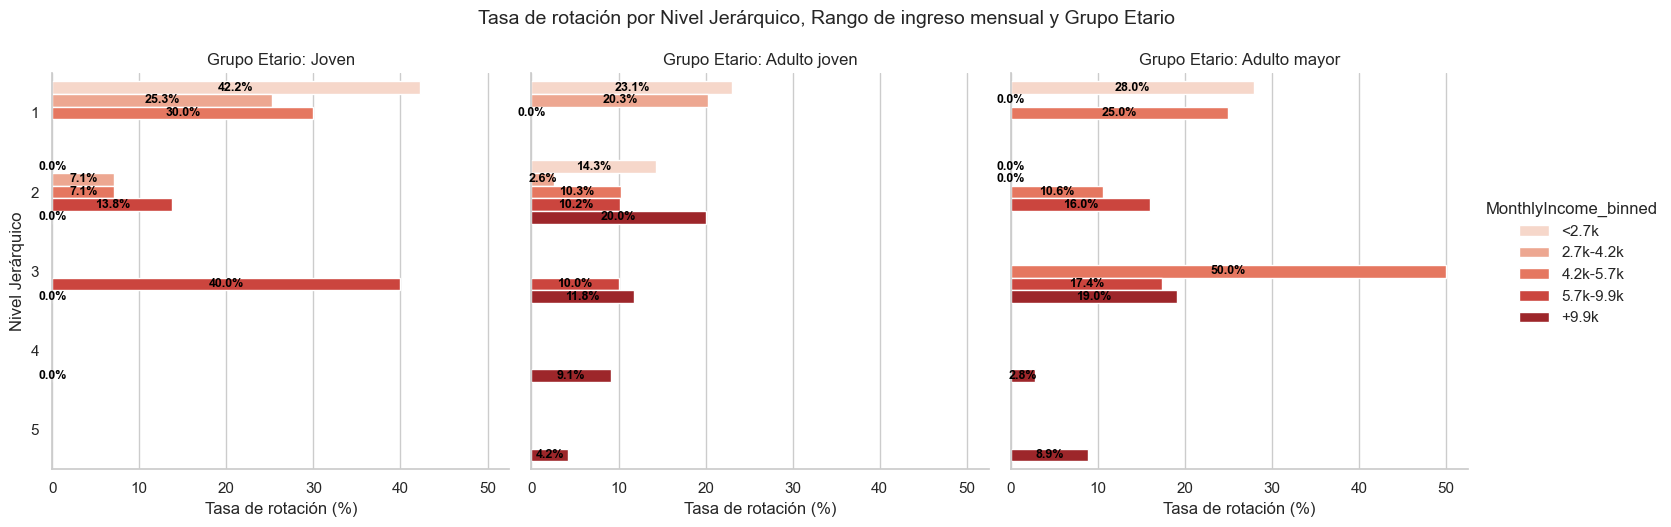

In [ ]:
# Gráfico de Tasa de rotación por Nivel Jerárquico, Rango de ingreso mensual y Grupo Etario

sns.set(style="whitegrid")

g = sns.catplot(
    data=demo_tab.reset_index(),
    kind='bar',
    y='JobLevel', x='Yes',
    hue='MonthlyIncome_binned',
    col='Age_binned',         # crea una columna por grupo de edad (realiza un facet grid)
    palette='Reds',
    errorbar=None,                  # elimina las barras negras
    height=5, aspect=1,
    sharex=True, sharey=True  # mantiene escalas comparables entre gráficos
)

# Etiquetas y título
g.set_axis_labels('Tasa de rotación (%)', 'Nivel Jerárquico')
g.set_titles(col_template='Grupo Etario: {col_name}')
g.fig.suptitle('Tasa de rotación por Nivel Jerárquico, Rango de ingreso mensual y Grupo Etario', 
               fontsize=14, y=1.05)

# Añadir porcentajes dentro de las barras
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='black', fontsize=9, weight='bold')

plt.show()


Interpretación:

- Relación entre salario y rotación
    - Los niveles salariales más bajos (<2.7k y 2.7k–4.2k) muestran tasas de rotación más altas (20–42%).
    - A partir de 4.2k–5.7k y superiores, la rotación disminuye drásticamente, en la mayoría de los casos por debajo del 15%.
Insight: el nivel de ingreso actúa como un amortiguador de la rotación , medida que los empleados ascienden salarialmente, la rotación cae.

- Influencia del nivel jerárquico (JobLevel)
    - JobLevel 1 (puestos administrativos iniciales):
        - Alta rotación, sobre todo en los jóvenes (<2.7k) con 42.18% de rotación .
        - Mejora con la edad o con el aumento salarial, pero sigue siendo el grupo más vulnerable.
    - JobLevel 2 (puestos intermedios):
        - Rotación mucho más bajo: entre 7% y 14% en la mayoría de los casos, lo cual indica que una vez que el empleado asciende, la probabilidad de permanecer aumenta notablemente.
    - JobLevel 3 y superiores:
        - En general, tasas de rotación  muy bajas (10%-19%), no obstante, existe casos atípicos (JobLevel 3 adultos mayores con 50%, probablemente casos específicos).
Insight: existe una relación inversa entre nivel jerárquico y rotación :a mayor nivel, menor probabilidad de salida de la empresa.

- Grupo Etario (Edad)
    - En casi todos los grupos, los jóvenes presentan las tasas más altas de rotación .
    - Los adultos jóvenes y adultos mayores muestran tendencia a la estabilidad, sobre todo cuando tienen mejor salario o posición jerárquica.
Insight: la edad modera el efecto del salario y del nivel jerárquico.

Patrones detectados:

- La rotación es una combinación de: jóvenes + menor salario + nivel jerárquico bajo (1) = alto riesgo de salida.
- La permanencia es una combinación de: adultos jóvenes o mayores + salario alto + nivel jerárquico ≥ 3, cuyas tasas de rotación entre 2% y 10%.

In [49]:
# Visualizar los roles por nivel jerárquico
# df.groupby(['JobLevel','JobRole'])['JobRole'].value_counts().reset_index()

In [50]:
# Análisis del dato atípico
# Revisión del tamaño del grupo, debido a que el nivel jerárquico tendría un dato atípico
df.groupby(['MonthlyIncome_binned', 'JobLevel', 'Age_binned']).size().reset_index()

C:\Users\USER\AppData\Local\Temp\ipykernel_48180\2965340128.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['MonthlyIncome_binned', 'JobLevel', 'Age_binned']).size().reset_index()


,MonthlyIncome_binned,JobLevel,Age_binned,0
0,<2.7k,1,Joven,128
1,<2.7k,1,Adulto joven,130
2,<2.7k,1,Adulto mayor,25
3,<2.7k,2,Joven,1
4,<2.7k,2,Adulto joven,7
5,<2.7k,2,Adulto mayor,3
6,<2.7k,3,Joven,0
7,<2.7k,3,Adulto joven,0
8,<2.7k,3,Adulto mayor,0
9,<2.7k,4,Joven,0


Análisis:

- Se evidencia que existen grupos pequeños (n < 10), es decir la muestra no es representativa:
    - Nivel 2 – rango < 2.7 k (1 – 7 personas) - No representativo.
    - Nivel 3 – rango 4.2 k–5.7 k (2 personas) - No representativo.
    - Nivel 4 – rango +9.9 k (1 persona) - No representativo.

In [51]:
#Obtener la mediana entre los distintos grupos etarios para cada nivel jerárquico y rango salarial
demo_tab_median = (demo_tab.reset_index().groupby(['MonthlyIncome_binned', 'JobLevel'])['Yes'].median().reset_index())


C:\Users\USER\AppData\Local\Temp\ipykernel_48180\3655947602.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo_tab_median = (demo_tab.reset_index().groupby(['MonthlyIncome_binned', 'JobLevel'])['Yes'].median().reset_index())


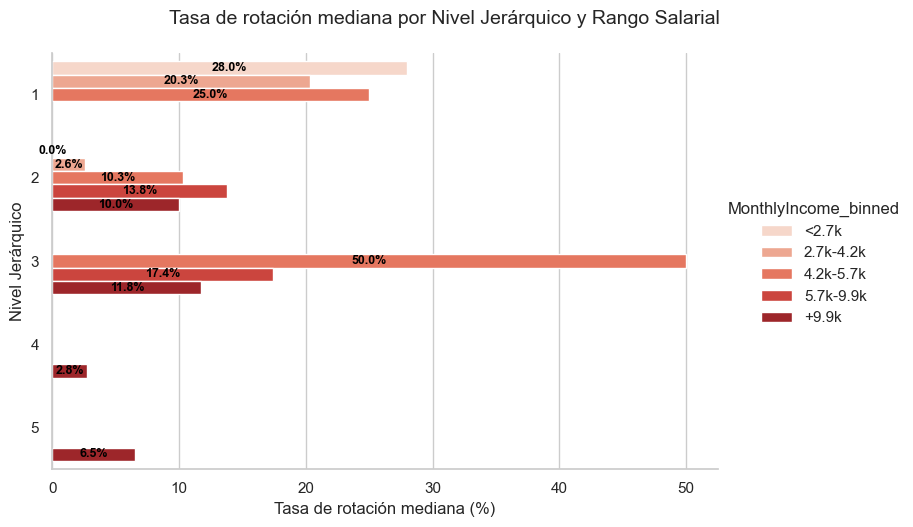

In [52]:
# Gráfica para visualizar el efecto del dato atípico utilizando la mediana

sns.set(style="whitegrid")
g = sns.catplot( data=demo_tab_median, kind='bar', y='JobLevel', x='Yes', hue='MonthlyIncome_binned', palette='Reds', height=5, aspect=1.5, errorbar=None)

g.set_axis_labels('Tasa de rotación mediana (%)', 'Nivel Jerárquico')
g.fig.suptitle('Tasa de rotación mediana por Nivel Jerárquico y Rango Salarial', fontsize=14, y=1.05)

for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='black', fontsize=9, weight='bold')

plt.show()


- Se evidencia que no hay corrección estadística, si el grupo tiene solo 2 observaciones, ya que la mediana, media devolverán lo mismo porque los datos son reales, pero no representativos.
- Por eso, se filtró los grupos no representativos, es decir, los valores extremos se excluyeron.

In [53]:
# Calcular tamaño de cada grupo
conteos = df.groupby(['MonthlyIncome_binned', 'JobLevel', 'Age_binned']).size().reset_index(name='n')

# Unir conteos a tu tabla de porcentajes
demo_tab = pd.crosstab( index=[df['MonthlyIncome_binned'], df['JobLevel'], df['Age_binned']], columns=df['Attrition'], normalize='index') * 100
demo_tab = demo_tab.reset_index().merge(conteos, on=['MonthlyIncome_binned','JobLevel','Age_binned'])

# Filtrar solo grupos con n >= 10
demo_tab_filtrado = demo_tab[demo_tab['n'] >= 10]


C:\Users\USER\AppData\Local\Temp\ipykernel_48180\1008384528.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteos = df.groupby(['MonthlyIncome_binned', 'JobLevel', 'Age_binned']).size().reset_index(name='n')


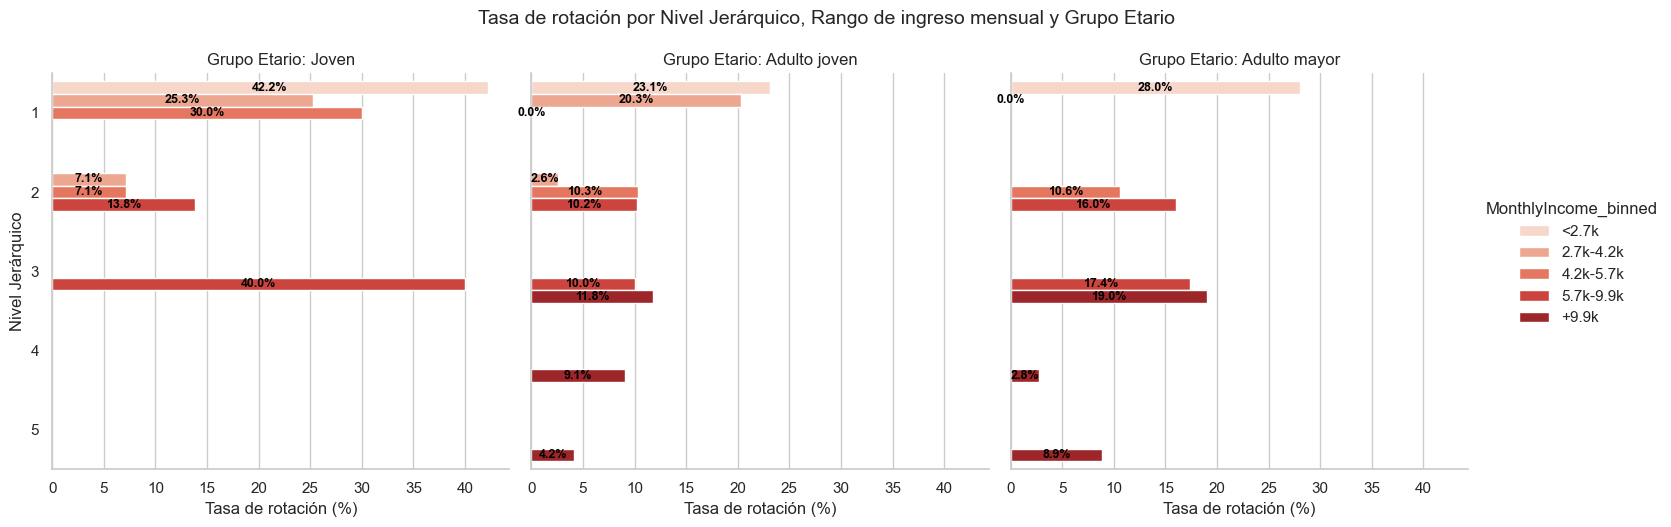

In [ ]:
# Gráfico de Tasa de rotación por Nivel Jerárquico, Rango de ingreso mensual y Grupo Etario

sns.set(style="whitegrid")

g = sns.catplot(
    data=demo_tab_filtrado.reset_index(),
    kind='bar',
    y='JobLevel', x='Yes',
    hue='MonthlyIncome_binned',
    col='Age_binned',         # crea una columna por grupo de edad (realiza un facet grid)
    palette='Reds',
    errorbar=None,                  # elimina las barras negras
    height=5, aspect=1,
    sharex=True, sharey=True  # mantiene escalas comparables entre gráficos
)

# Etiquetas y título
g.set_axis_labels('Tasa de rotación (%)', 'Nivel Jerárquico')
g.set_titles(col_template='Grupo Etario: {col_name}')
g.fig.suptitle('Tasa de rotación por Nivel Jerárquico, Rango de ingreso mensual y Grupo Etario', 
               fontsize=14, y=1.05)
# Observación: El título se ubica por encima del gráfico (y=1.05 es muy arriba) y (y=1.02 coloca dentro del área visible).
# El bounding box (el área que se exporta) no incluye elementos que están fuera del área principal, y el título queda cortado en el archivo PNG.


# Añadir porcentajes dentro de las barras
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='black', fontsize=9, weight='bold')


plt.savefig("grafico_transparente2.png", transparent=True, dpi=300,bbox_inches='tight')
plt.show()